### Importing

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay , classification_report , PrecisionRecallDisplay , RocCurveDisplay

### Loading Data

In [ ]:
df = pd.read_csv(filepath_or_buffer = "Mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### EDA

In [5]:
df.shape

(8124, 23)

In [6]:
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [9]:
df.info(verbose = False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Columns: 23 entries, class to habitat
dtypes: object(23)
memory usage: 1.4+ MB


In [12]:
df.describe().T.sort_values(by = ["unique"])

,count,unique,top,freq
veil-type,8124,1,p,8124
class,8124,2,e,4208
bruises,8124,2,f,4748
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
stalk-shape,8124,2,t,4608
ring-number,8124,3,o,7488
cap-surface,8124,4,y,3244
veil-color,8124,4,w,7924


In [13]:
df = df.drop(columns = ["veil-type"])

In [14]:
df["class"].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

### Preprocessing Data

In [15]:
target = df["class"]

In [17]:
df = pd.get_dummies(df.drop(columns = ["class"]) , drop_first = True , dtype = int)

### Feature & Target Split

In [19]:
X = df
y = target

### Train & Test Split

In [20]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 101)

### RandomizedSearchCV & Model Training

In [21]:
gbc_model = GradientBoostingClassifier(random_state = 101)

In [25]:
param_distributions = {
    "n_estimators" : [50 , 100 , 150] , 
    "max_depth" : [2 , 3 , 4 , 5 , 6 , 7] , 
    "learning_rate" : [0.05 , 0.5 , 0.2 , 0.1]
}

In [26]:
rf_model = RandomizedSearchCV(estimator = gbc_model , param_distributions = param_distributions , scoring = "accuracy" , cv = 5 ,
                              n_iter = 10 , random_state = 101)
rf_model.fit(X_train , y_train)
rf_model.best_params_

{'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.05}

### Predication

In [27]:
y_pred = rf_model.predict(X_test)

### Evaluation

In [29]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00      1050
           p       1.00      1.00      1.00       981

    accuracy                           1.00      2031
   macro avg       1.00      1.00      1.00      2031
weighted avg       1.00      1.00      1.00      2031



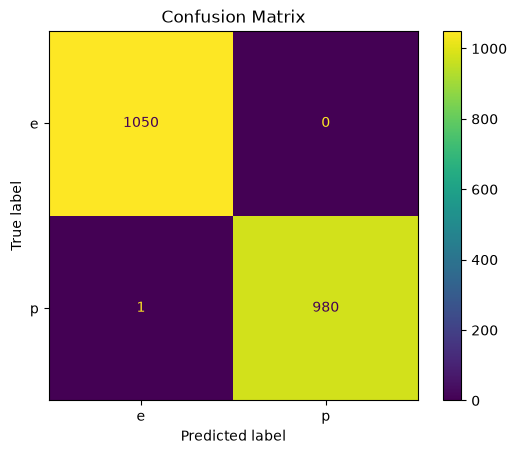

In [30]:
ConfusionMatrixDisplay.from_estimator(estimator = rf_model , X = X_test , y = y_test)
plt.title("Confusion Matrix")
plt.show()

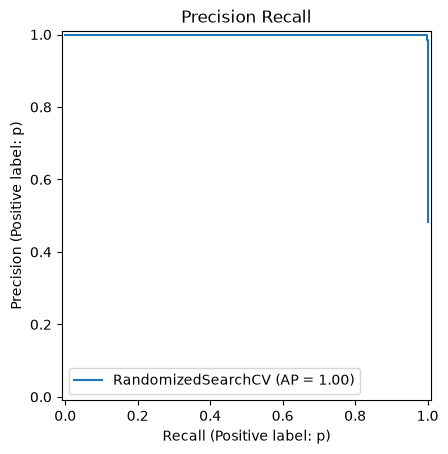

In [31]:
PrecisionRecallDisplay.from_estimator(estimator = rf_model , X = X_test , y = y_test)
plt.title("Precision Recall")
plt.show()

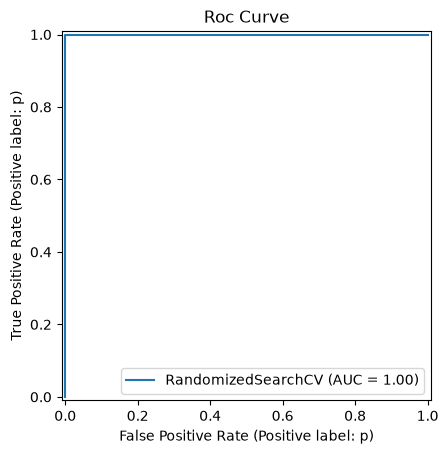

In [32]:
RocCurveDisplay.from_estimator(estimator = rf_model , X = X_test , y = y_test)
plt.title("Roc Curve")
plt.show()